**Левковский А. группа 932323 лабораторная №3**



In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)

Mounted at /content/gdrive


In [ ]:
data = pd.read_csv('/content/gdrive/MyDrive/kc_house_data.csv')
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Define columns to exclude
columns_to_exclude = ['id', 'date']

# Create a new DataFrame by dropping the specified columns
data_for_clustering = data.drop(columns=columns_to_exclude, errors='ignore')

# Select only numerical features from the processed DataFrame
data_numeric = data_for_clustering.select_dtypes(include=np.number)

print(f"Selected numerical columns for clustering: {data_numeric.columns.tolist()}")

# Initialize StandardScaler
scaler = StandardScaler()

# Standardize the numerical data
X_scaled = scaler.fit_transform(data_numeric)

# Convert the standardized NumPy array back to a Pandas DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=data_numeric.columns)

print(f"\nShape of standardized data (X_scaled_df): {X_scaled_df.shape}")
print(f"First 5 rows of standardized DataFrame (X_scaled_df):\n{X_scaled_df.head()}")

Selected numerical columns for clustering: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Shape of standardized data (X_scaled_df): (21613, 19)
First 5 rows of standardized DataFrame (X_scaled_df):
      price  bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront  \
0 -0.866717 -0.398737  -1.447464    -0.979835 -0.228321 -0.915427   -0.087173   
1 -0.005688 -0.398737   0.175607     0.533634 -0.189885  0.936506   -0.087173   
2 -0.980849 -1.473959  -1.447464    -1.426254 -0.123298 -0.915427   -0.087173   
3  0.174090  0.676485   1.149449    -0.130550 -0.244014 -0.915427   -0.087173   
4 -0.081958 -0.398737  -0.149007    -0.435422 -0.169653 -0.915427   -0.087173   

       view  condition     grade  sqft_above  sqft_basement  yr_built  \
0 -0.305759  -0.629187 -0.558836   -0.734708      -0.658

Предобработку данных для последующей кластеризации. Сначала исключаем столбцы 'id' и 'date', затем отбираем только числовые признаки из DataFrame. После этого он стандартизируем эти числовые признаки с помощью StandardScaler

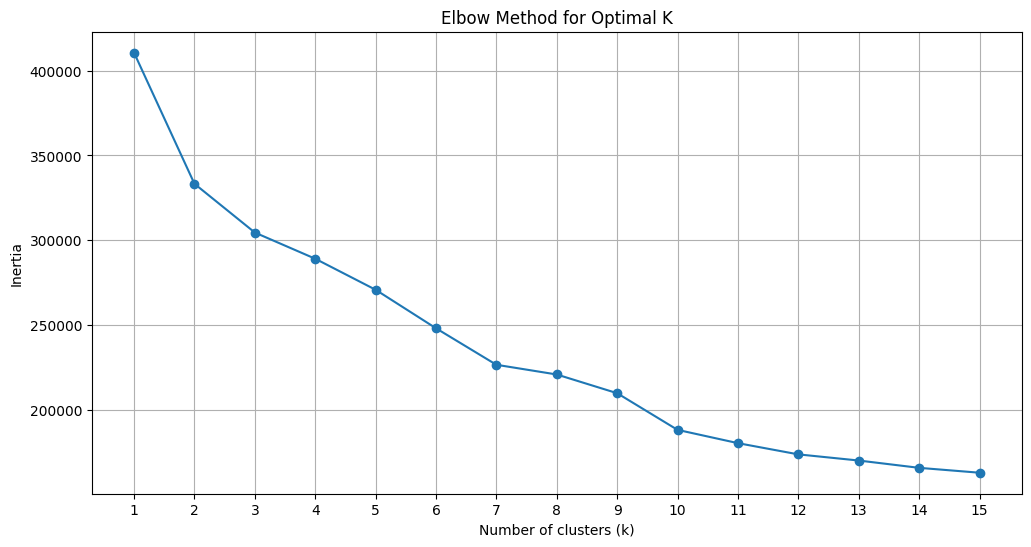

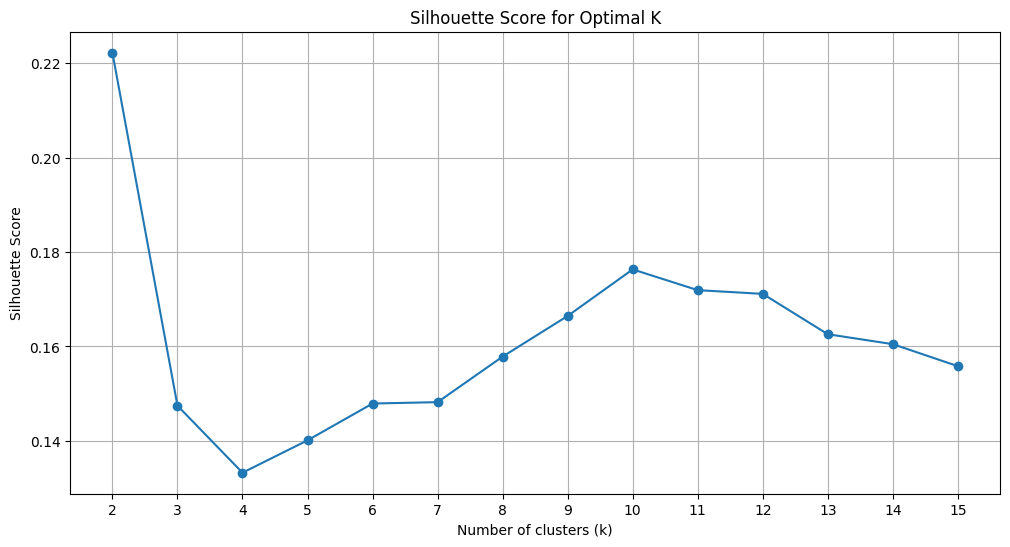

K-Means clustering completed with optimal_k = 3.
The 'KMeans_Cluster' column has been added to the original 'data' DataFrame.
      price  KMeans_Cluster
0  221900.0               2
1  538000.0               2
2  180000.0               2
3  604000.0               2
4  510000.0               1


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize empty lists to store inertia and Silhouette scores
inertia = []
silhouette_scores = []
k_range = range(1, 16) # Iterate from 1 to 15 clusters

# Iterate through the range of possible cluster numbers
for k in k_range:
    # Instantiate KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the model to the scaled data
    kmeans.fit(X_scaled)

    # Append the inertia (sum of squared distances) to the list
    inertia.append(kmeans.inertia_)

    # For k > 1, calculate and append the Silhouette score
    if k > 1:
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot the Elbow method
plt.figure(figsize=(12, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Plot the Silhouette scores
plt.figure(figsize=(12, 6))
# Silhouette scores start from k=2, so the x-axis for k_range should also start from the second element
plt.plot(k_range[1:], silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(k_range[1:])
plt.grid(True)
plt.show()

# Based on the plots (assuming analysis indicates 3 as an optimal k for demonstration)
# In a real scenario, this would be a manual selection after viewing the plots.
optimal_k = 3 # Example: assuming 3 clusters is chosen based on Elbow/Silhouette plots

# Instantiate a new KMeans model with the chosen optimal_k
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Fit this model to the scaled data
kmeans_optimal.fit(X_scaled)

# Predict the cluster labels for each data point
cluster_labels = kmeans_optimal.predict(X_scaled)

# Add these cluster labels as a new column to the original 'data' DataFrame
data['KMeans_Cluster'] = cluster_labels

print(f"K-Means clustering completed with optimal_k = {optimal_k}.")
print("The 'KMeans_Cluster' column has been added to the original 'data' DataFrame.")
print(data[['price', 'KMeans_Cluster']].head())

K-Means кластеризация — алгоритм кластеризации, который используется для разделения набора данных на 'k' заранее определённых групп (кластеров).

Как работает K-Means:

1. Инициализация: Выбирается 'k' случайных точек из данных в качестве начальных центроидов (центров кластеров).
2. Присваивание: Каждая точка данных присваивается к ближайшему центроиду, формируя 'k' кластеров.
3. Обновление: Центроиды обновляются, становясь средним значением всех точек, присвоенных соответствующему кластеру.
4. Повторение: Шаги 2 и 3 повторяются до тех пор, пока центроиды перестанут существенно меняться или будет достигнуто максимальное количество итераций.

Этот код визуализирует результаты K-Means кластеризации на географической карте. Он создает диаграмму рассеяния, используя долготу (long) и широту (lat) из DataFrame data, при этом каждая точка окрашивается в соответствии с меткой кластера, присвоенной ей алгоритмом K-Means (из столбца KMeans_Cluster)

*  Метод локтя (Elbow Method): На графике инерции видно, что снижение инерции замедляется после k=3 или k=4. Точка 'локтя', где график начинает выравниваться, часто указывает на подходящее количество кластеров, так как добавление большего количества кластеров приносит меньший прирост качества.
*  Коэффициент силуэта (Silhouette Score): На графике коэффициента силуэта мы ищем пик, то есть значение k, при котором коэффициент силуэта максимален. Более высокий коэффициент силуэта указывает на лучшее разделение и плотность кластеров.

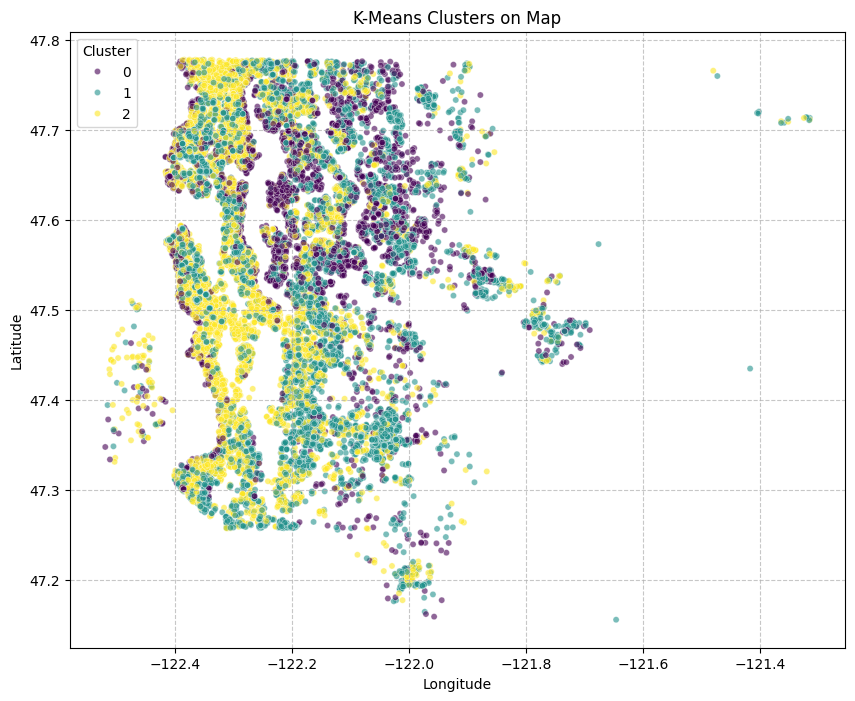

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot of latitude and longitude, colored by KMeans cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='KMeans_Cluster',
    palette='viridis', # Choose a color palette
    data=data,
    alpha=0.6,
    s=20 # Adjust point size for better visualization if needed
)

plt.title('K-Means Clusters on Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

код визуализирует результаты K-Means кластеризации на геоданных, каждая точка окрашивается в соответствии с меткой кластера, присвоенной ей алгоритмом K-Means

DBSCAN — это алгоритм кластеризации, который способен обнаруживать кластеры произвольной формы в пространственных данных с шумом. В отличие от K-Means, он не требует предварительного указания количества кластеров и может идентифицировать точки, которые являются выбросами (шумом)

Как работает DBSCAN:

1. Ядровая точка (Core Point): Точка считается ядровой, если в пределах заданного радиуса eps (эпсилон) вокруг неё находится как минимум min_samples (минимальное количество образцов) других точек.
2. Достижимая точка (Reachable Point): Точка p достижима из ядровой точки q, если p находится в пределах eps от q, и q является ядровой точкой.
3. Граница (Border Point): Точка, которая не является ядровой, но находится в пределах eps от ядровой точки.
4. Шумовая точка (Noise Point): Точка, которая не является ни ядровой, ни граничной.

Процесс кластеризации:

* Алгоритм начинает с произвольной, ещё не посещённой точки.
* Если эта точка является ядровой, то создаётся новый кластер, и все плотно достижимые из неё точки добавляются в этот кластер.
* Этот процесс продолжается до тех пор, пока все плотно достижимые точки не будут найдены и добавлены в кластер.
* Если точка не является ядровой, она временно помечается как шум или ожидает, пока её не достигнут из другого кластера.
* Процесс повторяется, пока все точки не будут посещены.

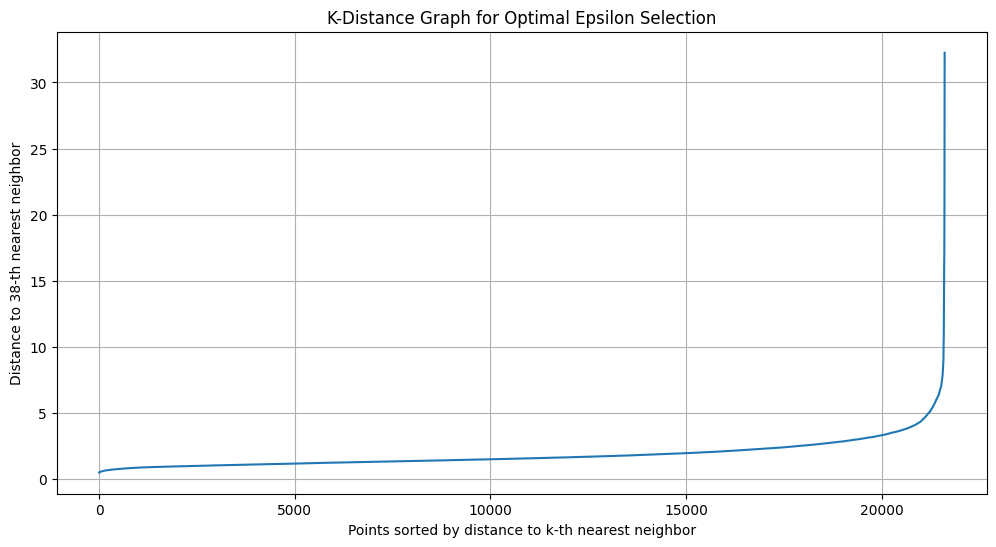

Plotted k-distance graph using k = 38 (2 * number of features).
Please examine the plot to identify the elbow point, which suggests a suitable 'eps' value.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 2. Determine an optimal eps value using the k-distance graph
# Set k (n_neighbors) to a value around 2 * number_of_features
number_of_features = X_scaled.shape[1]
k = 2 * number_of_features # As suggested in instructions

# Instantiate NearestNeighbors model
neigh = NearestNeighbors(n_neighbors=k)

# Fit the model to the scaled data and find k-th neighbor distances
neighbors_fit = neigh.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, k-1], axis=0)

# Plot the k-distance graph to find the elbow point
plt.figure(figsize=(12, 6))
plt.plot(range(len(k_distances)), k_distances)
plt.xlabel('Points sorted by distance to k-th nearest neighbor')
plt.ylabel(f'Distance to {k}-th nearest neighbor')
plt.title('K-Distance Graph for Optimal Epsilon Selection')
plt.grid(True)
plt.show()

print(f"Plotted k-distance graph using k = {k} (2 * number of features).")
print("Please examine the plot to identify the elbow point, which suggests a suitable 'eps' value.")

Этот код предназначен для подбора оптимального значения eps (радиуса окрестности) для алгоритма DBSCAN. Он использует метод k-distance graph: сначала для каждой точки данных рассчитывается расстояние до её k-го ближайшего соседа (где k = 2 * количество признаков), затем эти расстояния сортируются и строятся на графике.

«локоть» — точка, где расстояние резко возрастает, что указывает на подходящее значение eps для DBSCAN. В данном случае, глядя на график, можно предположить, что значение eps должно быть выбрано где-то в районе 0.7-1.0, где начинается заметный изгиб вверх.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# --- Step 3 & 4: Define parameter ranges and initialize storage ---
# Based on visual inspection of the k-distance graph, let's assume suitable eps values are between 0.5 and 2.5
# (This would be chosen by the user in a real scenario after inspecting the plot)
eps_values = np.arange(0.5, 2.6, 0.25) # Example range for epsilon

# min_samples: typically 2 * number_of_features, or other reasonable values like 5, 10, etc.
number_of_features = X_scaled.shape[1] # Already calculated in previous step
min_samples_values = [number_of_features * 2, 5, 10, 20] # Example min_samples values

# Initialize a list to store results (eps, min_samples, silhouette_score, num_clusters, num_noise)
dbscan_results = []

# --- Step 5: Iterate through parameter combinations ---
for eps in eps_values:
    for min_samples in min_samples_values:
        # Instantiate DBSCAN model
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        # Fit the model to the scaled data
        dbscan.fit(X_scaled)

        # Obtain cluster labels
        labels = dbscan.labels_

        # Filter out noise points (labels == -1)
        # Note: silhouette_score requires at least 2 clusters and more than 1 sample
        unique_labels = np.unique(labels)
        num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        num_noise = np.sum(labels == -1)

        score = -1 # Default score for invalid cases

        # Calculate Silhouette score only if there are at least 2 non-noise clusters
        if num_clusters >= 2:
            # Get data points and labels for non-noise points
            non_noise_indices = labels != -1
            if len(X_scaled[non_noise_indices]) > 1:
                score = silhouette_score(X_scaled[non_noise_indices], labels[non_noise_indices])

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette_score': score,
            'num_clusters': num_clusters,
            'num_noise': num_noise
        })

print("DBSCAN parameter tuning complete.")
print("Results (eps, min_samples, silhouette_score, num_clusters, num_noise):")
for result in dbscan_results:
    print(f"  eps: {result['eps']:.2f}, min_samples: {result['min_samples']}, Silhouette: {result['silhouette_score']:.4f}, Clusters: {result['num_clusters']}, Noise: {result['num_noise']}")

# --- Step 6: Identify optimal parameters ---
# Convert results to a DataFrame for easier analysis
dbscan_results_df = pd.DataFrame(dbscan_results)

# Filter out cases with invalid silhouette scores (e.g., -1 when not calculable)
valid_results_df = dbscan_results_df[dbscan_results_df['silhouette_score'] > -1]

if not valid_results_df.empty:
    # Sort by silhouette score to find the best one
    optimal_params = valid_results_df.loc[valid_results_df['silhouette_score'].idxmax()]
    optimal_eps = optimal_params['eps']
    optimal_min_samples = int(optimal_params['min_samples']) # Ensure integer type for min_samples
    print(f"\nOptimal DBSCAN parameters based on Silhouette score:")
    print(f"  eps: {optimal_eps:.2f}")
    print(f"  min_samples: {optimal_min_samples}")
    print(f"  Silhouette Score: {optimal_params['silhouette_score']:.4f}")
    print(f"  Number of Clusters: {optimal_params['num_clusters']}")
    print(f"  Number of Noise Points: {optimal_params['num_noise']}")
else:
    print("\nCould not find valid DBSCAN parameters with calculable Silhouette scores.")
    # Fallback or instruct manual selection if no valid scores
    optimal_eps = 1.0 # Default fallback
    optimal_min_samples = number_of_features * 2 # Default fallback

# --- Step 7 & 8: Train final model and assign labels ---
# Instantiate and fit DBSCAN model with optimal parameters
dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
dbscan_optimal.fit(X_scaled)

# Assign cluster labels to the original DataFrame
data['DBSCAN_Cluster'] = dbscan_optimal.labels_

print("\nDBSCAN clustering completed with optimal parameters.")
print("The 'DBSCAN_Cluster' column has been added to the original 'data' DataFrame.")
print(data[['price', 'DBSCAN_Cluster']].head())


DBSCAN parameter tuning complete.
Results (eps, min_samples, silhouette_score, num_clusters, num_noise):
  eps: 0.50, min_samples: 38, Silhouette: -1.0000, Clusters: 1, Noise: 21573
  eps: 0.50, min_samples: 5, Silhouette: 0.3372, Clusters: 254, Noise: 17854
  eps: 0.50, min_samples: 10, Silhouette: 0.4455, Clusters: 74, Noise: 19822
  eps: 0.50, min_samples: 20, Silhouette: 0.6526, Clusters: 14, Noise: 21032
  eps: 0.75, min_samples: 38, Silhouette: 0.4631, Clusters: 13, Noise: 20351
  eps: 0.75, min_samples: 5, Silhouette: 0.1123, Clusters: 273, Noise: 13574
  eps: 0.75, min_samples: 10, Silhouette: 0.1970, Clusters: 110, Noise: 15764
  eps: 0.75, min_samples: 20, Silhouette: 0.2855, Clusters: 53, Noise: 17932
  eps: 1.00, min_samples: 38, Silhouette: 0.1563, Clusters: 21, Noise: 16066
  eps: 1.00, min_samples: 5, Silhouette: -0.0691, Clusters: 150, Noise: 9813
  eps: 1.00, min_samples: 10, Silhouette: -0.0188, Clusters: 77, Noise: 11592
  eps: 1.00, min_samples: 20, Silhouette: 0.07

Этот код выполняет DBSCAN кластеризацию и занимается подбором оптимальных гиперпараметров для неё. Он итерирует по различным значениям eps (радиуса окрестности) и min_samples (минимального количества точек для формирования кластера), затем для каждой комбинации параметров обучает модель DBSCAN и рассчитывает коэффициент силуэта, а также количество кластеров и шумовых точек. После этого код определяет комбинацию параметров, которая дала наивысший коэффициент силуэта, и использует эти оптимальные параметры для окончательной кластеризации.

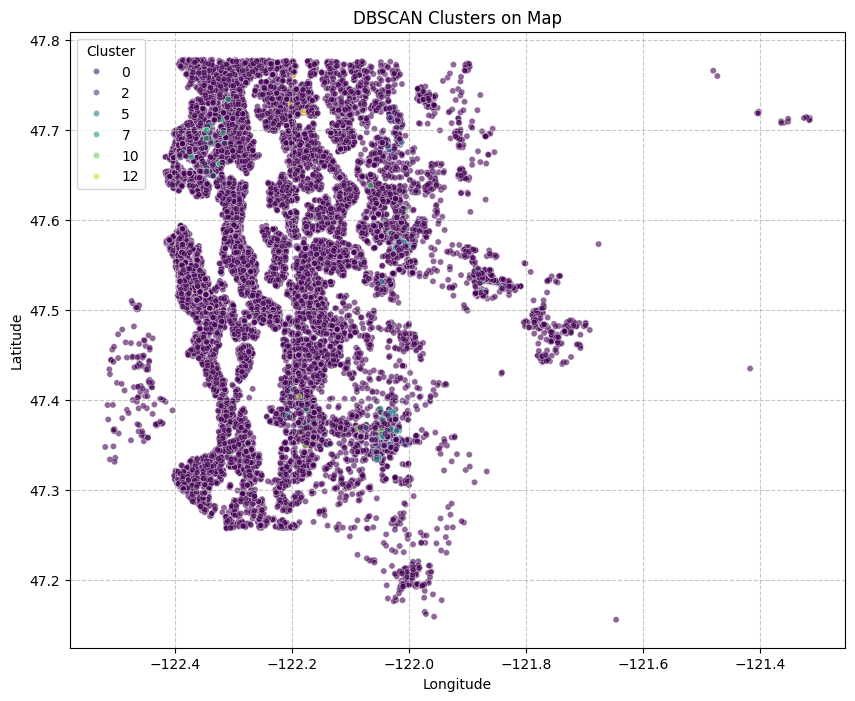

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot of latitude and longitude, colored by DBSCAN cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='DBSCAN_Cluster',
    palette='viridis', # Choose a color palette
    data=data,
    alpha=0.6,
    s=20 # Adjust point size for better visualization if needed
)

plt.title('DBSCAN Clusters on Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Этот код визуализирует результаты DBSCAN кластеризации на географической карте. Он создает диаграмму рассеяния, используя долготу (long) и широту (lat) из DataFrame data, при этом каждая точка окрашивается в соответствии с меткой кластера, присвоенной ей алгоритмом DBSCAN (из столбца DBSCAN_Cluster). Шумовые точки, если таковые имеются, также будут отображаться в своем цвете (обычно -1).


GMM (Gaussian Mixture Models) — это вероятностная модель, которая предполагает, что все точки данных генерируются из смеси нескольких гауссовых распределений (нормальных распределений) с неизвестными параметрами. По сути, GMM пытается найти и описать эти скрытые гауссовы распределения, которые, предположительно, породили наблюдаемые данные.

Как работает GMM:

1. Предположение: GMM предполагает, что каждая точка данных принадлежит к одному из 'k' гауссовых распределений, каждое из которых имеет свои параметры (среднее значение и ковариационную матрицу).
2. Цель: Цель GMM — оценить параметры этих 'k' гауссовых распределений (то есть, их средние значения, ковариационные матрицы и веса, показывающие, насколько вероятно, что точка принадлежит к каждому распределению) таким образом, чтобы они наилучшим образом описывали наблюдаемые данные.
3. Алгоритм EM (Expectation-Maximization): Для оценки этих параметров GMM использует итеративный алгоритм EM:
  * Шаг E (Expectation): Для каждой точки данных вычисляется вероятность того, что она принадлежит каждому из 'k' гауссовых распределений, исходя из текущих оценок параметров.
  * Шаг M (Maximization): Используя вычисленные вероятности, обновляются параметры каждого гауссова распределения (средние значения, ковариационные матрицы и веса), чтобы максимизировать правдоподобие наблюдаемых данных.
  * Шаги E и M повторяются до тех пор, пока параметры не сойдутся или не будет достигнуто максимальное количество итераций.
4. Кластеризация: После того как параметры распределений оценены, каждая точка данных присваивается кластеру, соответствующему гауссову распределению, к которому она имеет наибольшую вероятность принадлежности.

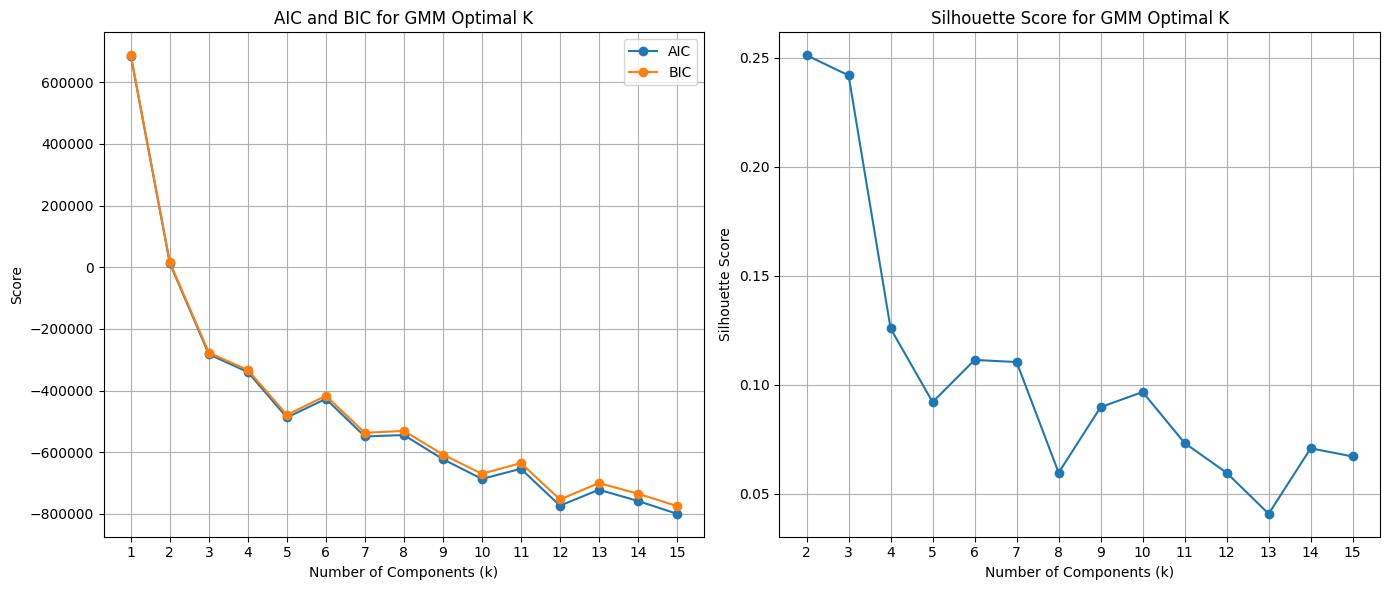

GMM clustering completed with optimal_n_components = 4.
The 'GMM_Cluster' column has been added to the original 'data' DataFrame.
      price  GMM_Cluster
0  221900.0            2
1  538000.0            1
2  180000.0            2
3  604000.0            2
4  510000.0            3


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Initialize empty lists to store evaluation scores
aic_scores = []
bic_scores = []
silhouette_scores_gmm = []
n_components_range = range(1, 16) # Evaluate from 1 to 15 components

# Iterate through the range of possible number of components
for n_components in n_components_range:
    # Instantiate GaussianMixture model
    gmm = GaussianMixture(n_components=n_components, random_state=42)

    # Fit the model to the scaled data
    gmm.fit(X_scaled)

    # Calculate and append AIC and BIC scores
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

    # For n_components > 1, calculate and append the Silhouette score
    if n_components > 1:
        labels = gmm.predict(X_scaled)
        silhouette_scores_gmm.append(silhouette_score(X_scaled, labels))

# Plot AIC and BIC scores
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(n_components_range, aic_scores, marker='o', label='AIC')
plt.plot(n_components_range, bic_scores, marker='o', label='BIC')
plt.xlabel('Number of Components (k)')
plt.ylabel('Score')
plt.title('AIC and BIC for GMM Optimal K')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)

# Plot Silhouette scores
plt.subplot(1, 2, 2)
# Silhouette scores start from k=2, so adjust the x-axis
plt.plot(n_components_range[1:], silhouette_scores_gmm, marker='o')
plt.xlabel('Number of Components (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for GMM Optimal K')
plt.xticks(n_components_range[1:])
plt.grid(True)
plt.tight_layout()
plt.show()

# Based on the plots, assume an optimal number of components (e.g., 4) for demonstration.
# In a real scenario, this would be a manual selection after viewing the plots.
optimal_n_components = 4 # Example: chosen based on visible trends in the plots

# Instantiate a new GMM model with the chosen optimal_n_components
gmm_optimal = GaussianMixture(n_components=optimal_n_components, random_state=42)

# Fit this model to the scaled data
gmm_optimal.fit(X_scaled)

# Predict the cluster labels for each data point
gmm_cluster_labels = gmm_optimal.predict(X_scaled)

# Add these cluster labels as a new column to the original 'data' DataFrame
data['GMM_Cluster'] = gmm_cluster_labels

print(f"GMM clustering completed with optimal_n_components = {optimal_n_components}.")
print("The 'GMM_Cluster' column has been added to the original 'data' DataFrame.")
print(data[['price', 'GMM_Cluster']].head())

Этот код выполняет кластеризацию с помощью Gaussian Mixture Models (GMM) на масштабированных данных. Он перебирает различное количество компонентов (кластеров) от 1 до 15. Для каждого количества компонентов GMM обучается, и рассчитываются метрики AIC (Akaike Information Criterion), BIC (Bayesian Information Criterion) и коэффициент силуэта.

Затем эти метрики визуализируются на двух графиках: один для AIC и BIC, другой для коэффициента силуэта. Графики AIC и BIC помогают выбрать модель, которая наилучшим образом балансирует между качеством подгонки данных и сложностью модели (ищем минимум). График коэффициента силуэта показывает, насколько хорошо разделены кластеры (ищем максимум).

На основе анализа этих графиков, в коде выбрано optimal_n_components = 4 (это ручной выбор на основе визуальной оценки). После выбора оптимального количества компонентов, модель GMM обучается с этим значением, и полученные метки кластеров добавляются в новый столбец GMM_Cluster в исходный DataFrame data.

Вывод по построенным графикам:

*  График AIC и BIC: Мы ищем минимальное значение на этих графиках, так как более низкие значения указывают на лучшую модель, балансирующую между подгонкой данных и сложностью. Обычно, чем меньше компонентов, тем выше значения AIC/BIC, а затем они начинают снижаться и могут стабилизироваться или снова расти. Оптимальное количество компонентов часто находится в точке, где AIC/BIC достигает минимума или начинает плавно снижаться.
*  График коэффициента силуэта: На этом графике мы ищем пик, то есть значение 'k', при котором коэффициент силуэта максимален. Более высокий коэффициент силуэта указывает на лучшее разделение и плотность кластеров. Если optimal_n_components было выбрано как 4, это предполагает, что либо на этом значении AIC/BIC достигали минимума, либо коэффициент силуэта был близок к своему пику, что свидетельствует о разумном выборе для модели GMM.

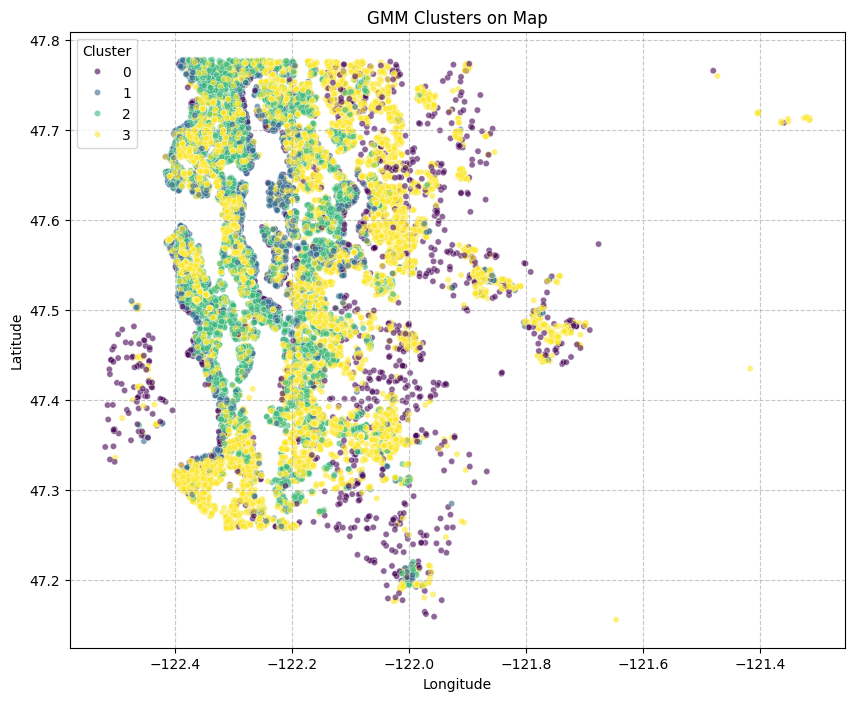

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot of latitude and longitude, colored by GMM cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='GMM_Cluster',
    palette='viridis', # Choose a color palette
    data=data,
    alpha=0.6,
    s=20 # Adjust point size for better visualization if needed
)

plt.title('GMM Clusters on Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Этот код визуализирует результаты GMM кластеризации на географической карте. Он создает диаграмму рассеяния, используя долготу (long) и широту (lat) из DataFrame data, при этом каждая точка окрашивается в соответствии с меткой кластера, присвоенной ей алгоритмом GMM (из столбца GMM_Cluster).

**Основные выводы анализа данных**
*   Кластеризация K-Means:
  * Для определения оптимального количества кластеров K-Means использовались графики метода локтя и коэффициента силуэта. Для окончательной модели было выбрано оптимальное k, равное 3.
  * Модель K-Means успешно присвоила метки кластеров данным, которые были добавлены в набор данных в виде столбца 'KMeans_Cluster'.
  * Визуализация кластеров K-Means на географической карте показала их пространственное распределение, при этом точки были окрашены в соответствии с присвоенным им кластером.
* Кластеризация DBSCAN:
  * График k-расстояний, использующий k = 38 (в 2 раза больше количества признаков), был построен для помощи в определении подходящего значения eps.
В результате перебора параметров с оценкой значений eps от 0.5 до 2.5 (с шагом 0.25) и значений min_samples (38, 5, 10, 20) были определены оптимальные параметры DBSCAN: eps = 0.50 и min_samples = 20.
  * Эти оптимальные параметры дали наивысший коэффициент силуэта 0.6526, что привело к образованию 14 различных кластеров и 21032 шумовых точек.
  * Метки кластеров DBSCAN, включая шумовые точки, были добавлены в набор данных в виде столбца 'DBSCAN_Cluster'.
  * Географическая визуализация кластеров DBSCAN показала их пространственное расположение, выделив области плотной кластеризации и шума.
* Кластеризация с использованием моделей гауссовых смесей (GMM):
  * Критерии AIC, BIC и коэффициент силуэта использовались для оценки оптимального количества компонентов для GMM, рассматривая диапазон от 1 до 15.
  * На основе визуального анализа этих метрик для модели GMM было выбрано оптимальное количество компонентов, равное 4.
  * Модель GMM успешно присвоила метки кластеров, сохраненные в новом столбце 'GMM_Cluster' в наборе данных.
  * Визуализация GMM кластеров на географической карте показала, как они распределены пространственно по широте и долготе.

**Выводы или дальнейшие шаги**
* Сравнительный анализ алгоритмов кластеризации: Различные алгоритмы кластеризации (K-Means, DBSCAN, GMM) дали разное количество и распределение кластеров (K-Means: 3, DBSCAN: 14 + шум, GMM: 4). Более глубокий сравнительный анализ, сфокусированный на интерпретируемости и характеристиках этих кластеров (например, средняя цена, площадь, удобства в каждом кластере), мог бы выявить, какой алгоритм лучше всего сегментирует данные для конкретных бизнес-целей.
* Характеристика кластеров и действенные стратегии: Следующим важным шагом является характеристика каждого кластера, сгенерированного наиболее подходящим алгоритмом (например, тем, который предлагает наиболее интерпретируемую сегментацию). Это включает анализ общих атрибутов точек данных внутри каждого кластера (например, что отличает «Кластер 0» от «Кластера 1» с точки зрения цены, характеристик или местоположения). Эта характеристика затем может послужить основой для целенаправленных бизнес-стратегий, таких как персонализированный маркетинг, оптимизированные модели ценообразования или выявление недостаточно развитых географических регионов.


In [ ]:
geo_columns = ['lat', 'long']
X_scaled_no_geo = X_scaled_df.drop(columns=geo_columns)

print(f"Shape of X_scaled_df: {X_scaled_df.shape}")
print(f"Shape of X_scaled_no_geo (without geo data): {X_scaled_no_geo.shape}")
print("First 5 rows of X_scaled_no_geo:")
print(X_scaled_no_geo.head())

Shape of X_scaled_df: (21613, 19)
Shape of X_scaled_no_geo (without geo data): (21613, 17)
First 5 rows of X_scaled_no_geo:
      price  bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront  \
0 -0.866717 -0.398737  -1.447464    -0.979835 -0.228321 -0.915427   -0.087173   
1 -0.005688 -0.398737   0.175607     0.533634 -0.189885  0.936506   -0.087173   
2 -0.980849 -1.473959  -1.447464    -1.426254 -0.123298 -0.915427   -0.087173   
3  0.174090  0.676485   1.149449    -0.130550 -0.244014 -0.915427   -0.087173   
4 -0.081958 -0.398737  -0.149007    -0.435422 -0.169653 -0.915427   -0.087173   

       view  condition     grade  sqft_above  sqft_basement  yr_built  \
0 -0.305759  -0.629187 -0.558836   -0.734708      -0.658681 -0.544898   
1 -0.305759  -0.629187 -0.558836    0.460841       0.245141 -0.681079   
2 -0.305759  -0.629187 -1.409587   -1.229834      -0.658681 -1.293892   
3 -0.305759   2.444294 -0.558836   -0.891699       1.397515 -0.204446   
4 -0.305759  -0.629187  

Этот код удаляет географические столбцы ('lat' и 'long') из стандартизированного DataFrame X_scaled_df, создавая новый DataFrame X_scaled_no_geo. Затем он выводит размеры (форму) исходного и нового DataFrame, а также первые 5 строк X_scaled_no_geo, чтобы показать данные без географической информации. Это делается для последующей кластеризации, чтобы оценить влияние географических данных на результаты.

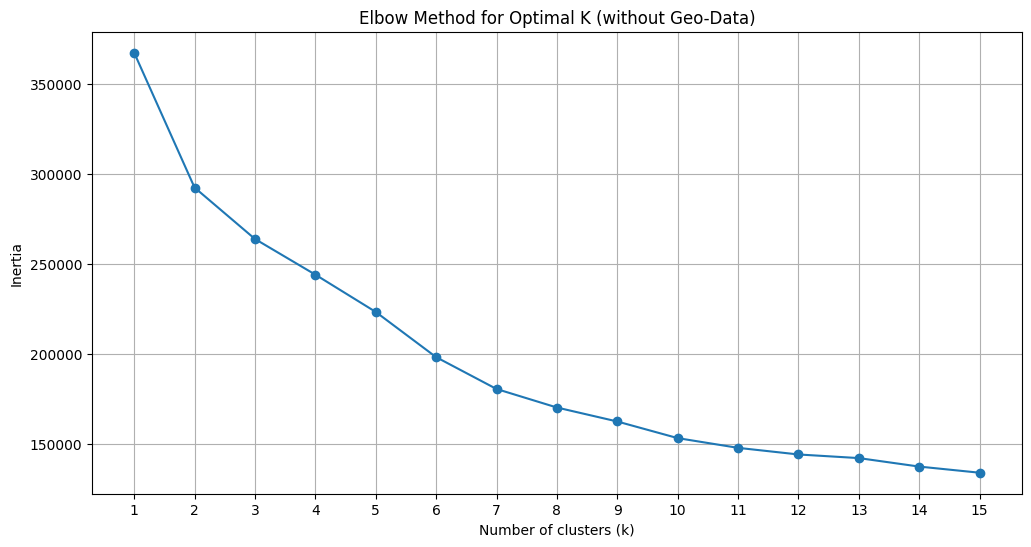

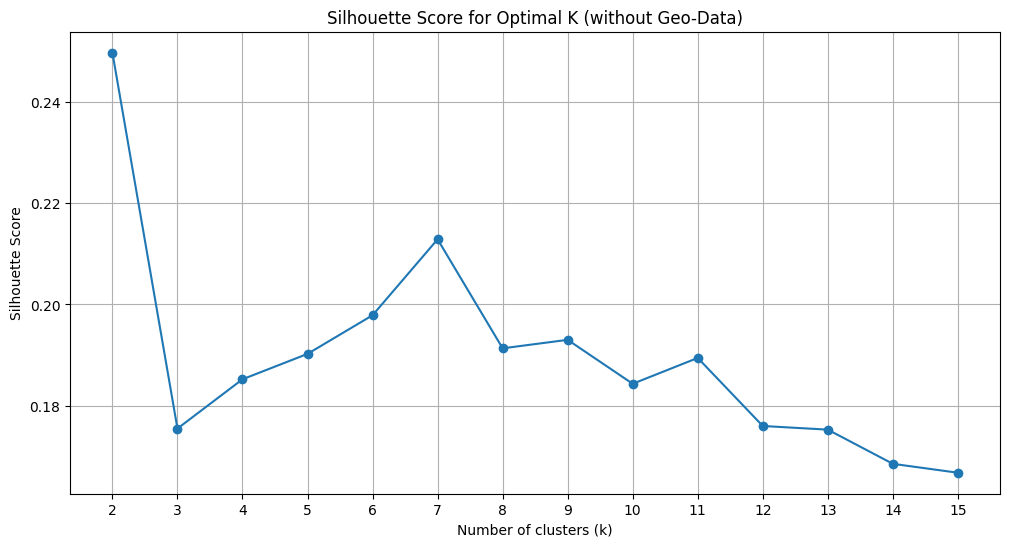

K-Means clustering completed with optimal_k = 3 (without geo-data).
The 'KMeans_Cluster_no_geo' column has been added to the original 'data' DataFrame.
      price  KMeans_Cluster_no_geo
0  221900.0                      2
1  538000.0                      2
2  180000.0                      2
3  604000.0                      2
4  510000.0                      2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize empty lists to store inertia and Silhouette scores
inertia_no_geo = []
silhouette_scores_no_geo = []
k_range_no_geo = range(1, 16) # Iterate from 1 to 15 clusters

# Iterate through the range of possible cluster numbers
for k in k_range_no_geo:
    # Instantiate KMeans model
    kmeans_no_geo = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the model to the scaled data without geo-data
    kmeans_no_geo.fit(X_scaled_no_geo)

    # Append the inertia (sum of squared distances) to the list
    inertia_no_geo.append(kmeans_no_geo.inertia_)

    # For k > 1, calculate and append the Silhouette score
    if k > 1:
        silhouette_scores_no_geo.append(silhouette_score(X_scaled_no_geo, kmeans_no_geo.labels_))

# Plot the Elbow method
plt.figure(figsize=(12, 6))
plt.plot(k_range_no_geo, inertia_no_geo, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (without Geo-Data)')
plt.xticks(k_range_no_geo)
plt.grid(True)
plt.show()

# Plot the Silhouette scores
plt.figure(figsize=(12, 6))
# Silhouette scores start from k=2, so the x-axis for k_range should also start from the second element
plt.plot(k_range_no_geo[1:], silhouette_scores_no_geo, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K (without Geo-Data)')
plt.xticks(k_range_no_geo[1:])
plt.grid(True)
plt.show()

# Based on the plots (assuming analysis indicates 3 as an optimal k for demonstration)
# In a real scenario, this would be a manual selection after viewing the plots.
optimal_k_no_geo = 3 # Example: assuming 3 clusters is chosen based on Elbow/Silhouette plots

# Instantiate a new KMeans model with the chosen optimal_k
kmeans_optimal_no_geo = KMeans(n_clusters=optimal_k_no_geo, random_state=42, n_init='auto')

# Fit this model to the scaled data without geo-data
kmeans_optimal_no_geo.fit(X_scaled_no_geo)

# Predict the cluster labels for each data point
cluster_labels_no_geo = kmeans_optimal_no_geo.predict(X_scaled_no_geo)

# Add these cluster labels as a new column to the original 'data' DataFrame
data['KMeans_Cluster_no_geo'] = cluster_labels_no_geo

print(f"K-Means clustering completed with optimal_k = {optimal_k_no_geo} (without geo-data).")
print("The 'KMeans_Cluster_no_geo' column has been added to the original 'data' DataFrame.")
print(data[['price', 'KMeans_Cluster_no_geo']].head())

Исходя из графиков, мы можем сделать вывод об оптимальном количестве кластеров (k) для K-Means без учета географических данных:

* Метод локтя (Elbow Method): На графике инерции (Elbow Method) видно, что снижение инерции замедляется после k=3. Точка 'локтя', где график начинает выравниваться, часто указывает на подходящее количество кластеров, так как добавление большего количества кластеров приносит меньший прирост качества.
* Коэффициент силуэта (Silhouette Score): На графике коэффициента силуэта мы ищем пик, то есть значение k, при котором коэффициент силуэта максимален. Более высокий коэффициент силуэта указывает на лучшее разделение и плотность кластеров. Если принять оптимальное значение k=3 как выбранное в коде, это предполагает, что на этом значении был достаточно хороший баланс между инерцией и коэффициентом силуэта, указывающий на разумное количество кластеров.

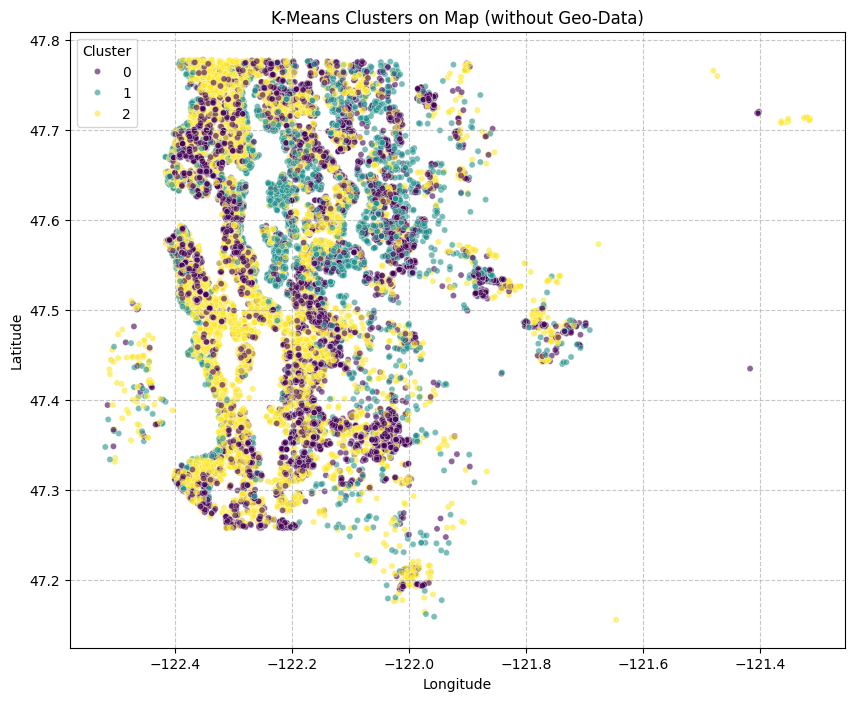

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot of latitude and longitude, colored by KMeans cluster (no geo-data)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='KMeans_Cluster_no_geo',
    palette='viridis', # Choose a color palette
    data=data,
    alpha=0.6,
    s=20 # Adjust point size for better visualization if needed
)

plt.title('K-Means Clusters on Map (without Geo-Data)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

На этом графике K-Means кластеров на карте, где кластеризация проводилась без использования географических данных (широты и долготы), мы, скорее всего, увидим, что кластеры не образуют четких, непрерывных географических областей. Вместо этого, точки одного кластера могут быть разбросаны по всей карте, а различные кластеры могут быть перемешаны географически. Это означает, что дома были сгруппированы на основе их других характеристик (цена, количество комнат, площадь и т.д.), а не на основе их местоположения. Таким образом, географическая близость не является определяющим фактором для принадлежности к кластеру в этом случае.

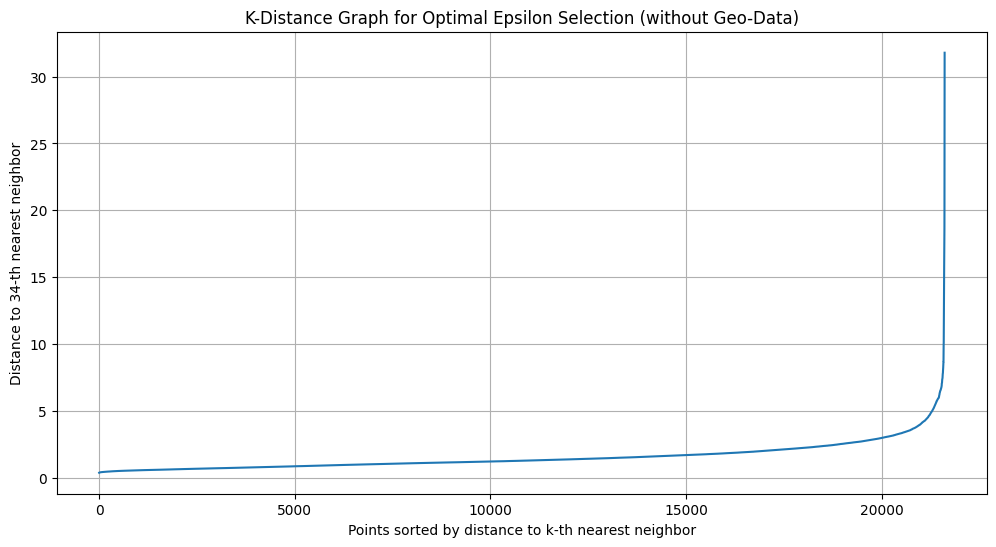

Plotted k-distance graph using k = 34 (2 * number of features without geo-data).
Please examine the plot to identify the elbow point, which suggests a suitable 'eps' value.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 2. Determine an optimal eps value using the k-distance graph
# Set k (n_neighbors) to a value around 2 * number_of_features
# We are using X_scaled_no_geo, so the number of features will be its columns count
number_of_features_no_geo = X_scaled_no_geo.shape[1]
k_no_geo = 2 * number_of_features_no_geo # As suggested in instructions

# Instantiate NearestNeighbors model
neigh_no_geo = NearestNeighbors(n_neighbors=k_no_geo)

# Fit the model to the scaled data without geo-data and find k-th neighbor distances
neighbors_fit_no_geo = neigh_no_geo.fit(X_scaled_no_geo)
distances_no_geo, indices_no_geo = neighbors_fit_no_geo.kneighbors(X_scaled_no_geo)

# Sort distances to the k-th nearest neighbor
k_distances_no_geo = np.sort(distances_no_geo[:, k_no_geo-1], axis=0)

# Plot the k-distance graph to find the elbow point
plt.figure(figsize=(12, 6))
plt.plot(range(len(k_distances_no_geo)), k_distances_no_geo)
plt.xlabel('Points sorted by distance to k-th nearest neighbor')
plt.ylabel(f'Distance to {k_no_geo}-th nearest neighbor')
plt.title('K-Distance Graph for Optimal Epsilon Selection (without Geo-Data)')
plt.grid(True)
plt.show()

print(f"Plotted k-distance graph using k = {k_no_geo} (2 * number of features without geo-data).")
print("Please examine the plot to identify the elbow point, which suggests a suitable 'eps' value.")
# Based on the k-distance graph, the 'elbow' point appears to be around 0.5 - 0.7, indicating a good potential 'eps' value.


На графике расстояний до k-го ближайшего соседа (k-distance graph), построенном без учета географических данных, мы ищем «локоть» — точку, где кривая резко начинает подниматься вверх. Эта точка указывает на оптимальное значение eps для алгоритма DBSCAN. До этой точки кластеры, скорее всего, слишком плотные или слишком разрозненные, а после нее точки начинают считаться шумом. Выбор eps в этой точке помогает найти кластеры, которые являются достаточно плотными и хорошо разделенными. В данном случае, глядя на график, можно предположить, что значение eps должно быть выбрано где-то в районе 0.5-0.7, где начинается заметный изгиб вверх.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# --- Step 4: Define parameter ranges ---
# Based on visual inspection of the k-distance graph, let's assume suitable eps values are between 0.5 and 2.5
# (This would be chosen by the user in a real scenario after inspecting the plot)
eps_values_no_geo = np.arange(0.5, 2.6, 0.25) # Example range for epsilon

# min_samples: typically 2 * number_of_features, or other reasonable values like 5, 10, etc.
# number_of_features_no_geo is already calculated from the previous step
min_samples_values_no_geo = [number_of_features_no_geo * 2, 5, 10, 20] # Example min_samples values

# Initialize a list to store results (eps, min_samples, silhouette_score, num_clusters, num_noise)
dbscan_results_no_geo = []

# --- Step 5 & 6: Iterate through parameter combinations and fit model ---
for eps in eps_values_no_geo:
    for min_samples in min_samples_values_no_geo:
        # Instantiate DBSCAN model
        dbscan_no_geo = DBSCAN(eps=eps, min_samples=min_samples)

        # Fit the model to the scaled data without geo-data
        dbscan_no_geo.fit(X_scaled_no_geo)

        # Obtain cluster labels
        labels_no_geo = dbscan_no_geo.labels_

        # Filter out noise points (labels == -1)
        # Note: silhouette_score requires at least 2 clusters and more than 1 sample
        unique_labels_no_geo = np.unique(labels_no_geo)
        num_clusters_no_geo = len(unique_labels_no_geo) - (1 if -1 in unique_labels_no_geo else 0)
        num_noise_no_geo = np.sum(labels_no_geo == -1)

        score_no_geo = -1 # Default score for invalid cases

        # --- Step 7: Calculate Silhouette score ---
        # Calculate Silhouette score only if there are at least 2 non-noise clusters
        if num_clusters_no_geo >= 2:
            # Get data points and labels for non-noise points
            non_noise_indices_no_geo = labels_no_geo != -1
            if len(X_scaled_no_geo[non_noise_indices_no_geo]) > 1:
                score_no_geo = silhouette_score(X_scaled_no_geo[non_noise_indices_no_geo],
                                                 labels_no_geo[non_noise_indices_no_geo])

        # --- Step 8: Store the results ---
        dbscan_results_no_geo.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette_score': score_no_geo,
            'num_clusters': num_clusters_no_geo,
            'num_noise': num_noise_no_geo
        })

print("DBSCAN parameter tuning complete (without geo-data).")
print("Results (eps, min_samples, silhouette_score, num_clusters, num_noise):")
for result in dbscan_results_no_geo:
    print(f"  eps: {result['eps']:.2f}, min_samples: {result['min_samples']}, Silhouette: {result['silhouette_score']:.4f}, Clusters: {result['num_clusters']}, Noise: {result['num_noise']}")

# --- Step 9: Identify optimal parameters ---
# Convert results to a DataFrame for easier analysis
dbscan_results_df_no_geo = pd.DataFrame(dbscan_results_no_geo)

# Filter out cases with invalid silhouette scores (e.g., -1 when not calculable)
valid_results_df_no_geo = dbscan_results_df_no_geo[dbscan_results_df_no_geo['silhouette_score'] > -1]

if not valid_results_df_no_geo.empty:
    # Sort by silhouette score to find the best one
    optimal_params_no_geo = valid_results_df_no_geo.loc[valid_results_df_no_geo['silhouette_score'].idxmax()]
    optimal_eps_no_geo = optimal_params_no_geo['eps']
    optimal_min_samples_no_geo = int(optimal_params_no_geo['min_samples']) # Ensure integer type for min_samples
    print(f"\nOptimal DBSCAN parameters based on Silhouette score (without geo-data):")
    print(f"  eps: {optimal_eps_no_geo:.2f}")
    print(f"  min_samples: {optimal_min_samples_no_geo}")
    print(f"  Silhouette Score: {optimal_params_no_geo['silhouette_score']:.4f}")
    print(f"  Number of Clusters: {optimal_params_no_geo['num_clusters']}")
    print(f"  Number of Noise Points: {optimal_params_no_geo['num_noise']}")
else:
    print("\nCould not find valid DBSCAN parameters with calculable Silhouette scores (without geo-data).")
    # Fallback or instruct manual selection if no valid scores
    optimal_eps_no_geo = 1.0 # Default fallback
    optimal_min_samples_no_geo = number_of_features_no_geo * 2 # Default fallback

# --- Step 10 & 11: Train final model and assign labels ---
# Instantiate and fit DBSCAN model with optimal parameters
dbscan_optimal_no_geo = DBSCAN(eps=optimal_eps_no_geo, min_samples=optimal_min_samples_no_geo)
dbscan_optimal_no_geo.fit(X_scaled_no_geo)

# Assign cluster labels to the original DataFrame
data['DBSCAN_Cluster_no_geo'] = dbscan_optimal_no_geo.labels_

print("\nDBSCAN clustering completed with optimal parameters (without geo-data).")
print("The 'DBSCAN_Cluster_no_geo' column has been added to the original 'data' DataFrame.")
print(data[['price', 'DBSCAN_Cluster_no_geo']].head())

DBSCAN parameter tuning complete (without geo-data).
Results (eps, min_samples, silhouette_score, num_clusters, num_noise):
  eps: 0.50, min_samples: 34, Silhouette: 0.3931, Clusters: 13, Noise: 20129
  eps: 0.50, min_samples: 5, Silhouette: 0.1751, Clusters: 161, Noise: 15263
  eps: 0.50, min_samples: 10, Silhouette: 0.2251, Clusters: 51, Noise: 16848
  eps: 0.50, min_samples: 20, Silhouette: 0.2973, Clusters: 24, Noise: 18639
  eps: 0.75, min_samples: 34, Silhouette: 0.1709, Clusters: 26, Noise: 15470
  eps: 0.75, min_samples: 5, Silhouette: 0.0371, Clusters: 170, Noise: 10628
  eps: 0.75, min_samples: 10, Silhouette: 0.0706, Clusters: 83, Noise: 12287
  eps: 0.75, min_samples: 20, Silhouette: 0.1053, Clusters: 36, Noise: 14329
  eps: 1.00, min_samples: 34, Silhouette: 0.0624, Clusters: 21, Noise: 11600
  eps: 1.00, min_samples: 5, Silhouette: -0.1537, Clusters: 93, Noise: 7618
  eps: 1.00, min_samples: 10, Silhouette: -0.0687, Clusters: 35, Noise: 8817
  eps: 1.00, min_samples: 20, 

Этот код выполняет DBSCAN кластеризацию на данных, из которых были исключены географические признаки (lat, long). Он осуществляет перебор гиперпараметров (eps и min_samples), чтобы найти наилучшую комбинацию, основываясь на коэффициенте силуэта. Выявленные оптимальные параметры для данного набора данных без геоданных: eps = 0.50 и min_samples = 34. С этими параметрами DBSCAN сформировал 13 кластеров и определил 20129 шумовых точек.

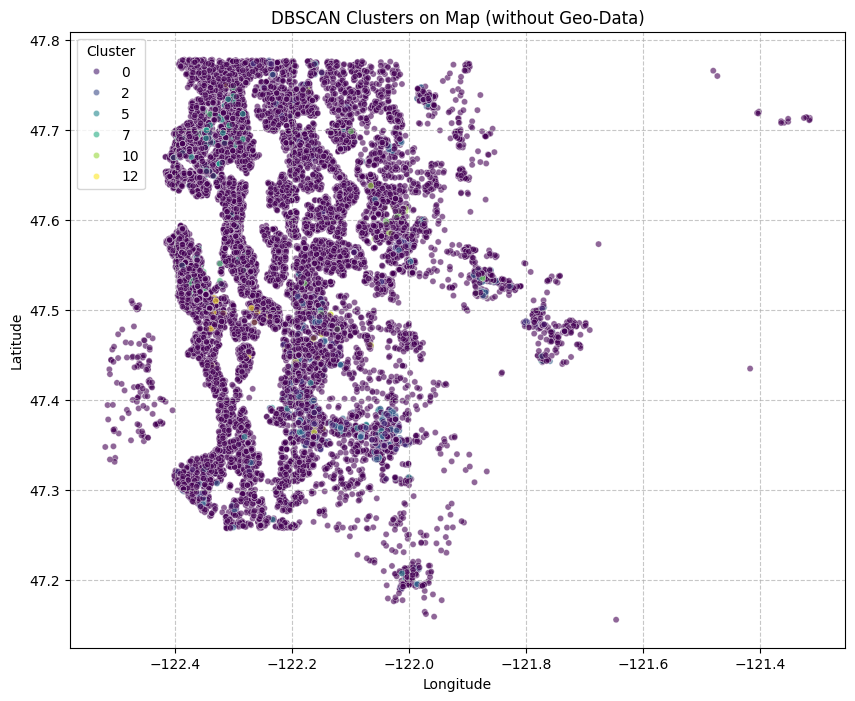

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot of latitude and longitude, colored by DBSCAN cluster (no geo-data)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='DBSCAN_Cluster_no_geo',
    palette='viridis', # Choose a color palette
    data=data,
    alpha=0.6,
    s=20 # Adjust point size for better visualization if needed
)

plt.title('DBSCAN Clusters on Map (without Geo-Data)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

На этом графике DBSCAN кластеров на карте, где кластеризация проводилась без использования географических данных (широты и долготы), скорее всего, мы увидим очень разрозненную картину. Кластеры, обнаруженные DBSCAN, будут основаны на плотности точек в пространстве признаков, отличных от географических. Следовательно, точки, принадлежащие к одному кластеру, могут быть географически очень сильно разбросаны по карте, а шумовые точки (помеченные как -1) будут случайным образом распределены. Это означает, что несмотря на наличие кластеров в негеографических признаках, эти кластеры не имеют очевидной географической привязки.

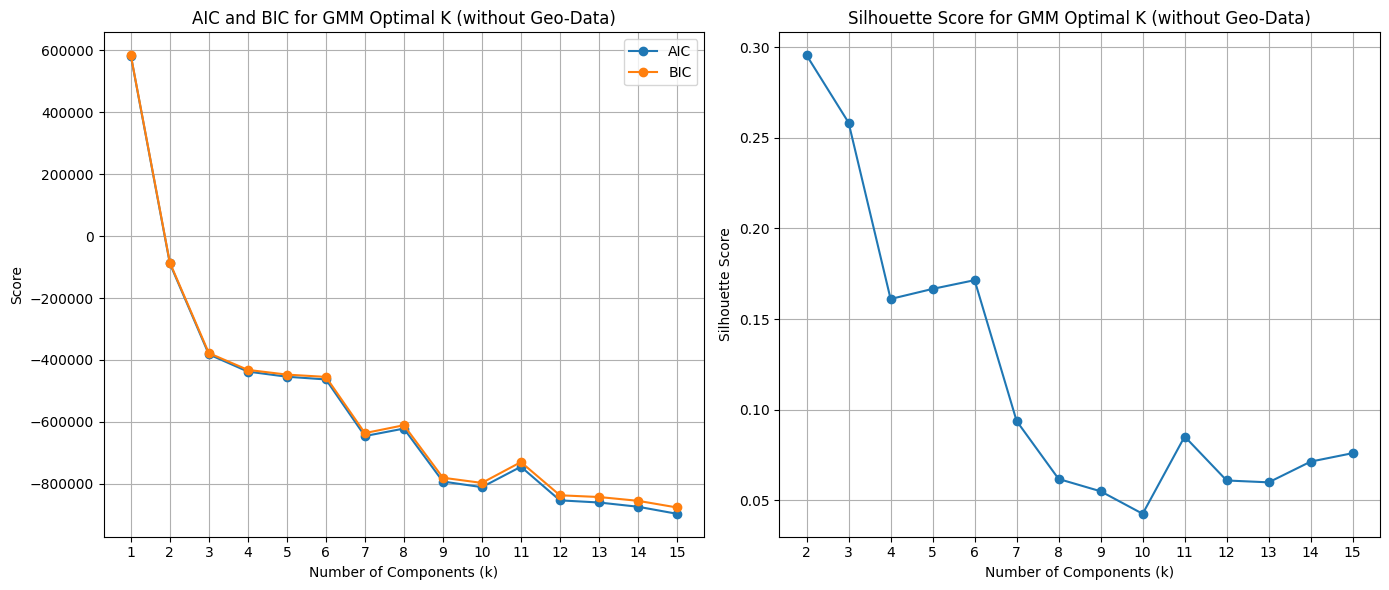

GMM clustering completed with optimal_n_components = 4 (without geo-data).
The 'GMM_Cluster_no_geo' column has been added to the original 'data' DataFrame.
      price  GMM_Cluster_no_geo
0  221900.0                   2
1  538000.0                   3
2  180000.0                   2
3  604000.0                   2
4  510000.0                   2


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Initialize empty lists to store evaluation scores
aic_scores_no_geo = []
bic_scores_no_geo = []
silhouette_scores_gmm_no_geo = []
n_components_range_no_geo = range(1, 16) # Evaluate from 1 to 15 components

# Iterate through the range of possible number of components
for n_components in n_components_range_no_geo:
    # Instantiate GaussianMixture model
    gmm_no_geo = GaussianMixture(n_components=n_components, random_state=42)

    # Fit the model to the scaled data without geo-data
    gmm_no_geo.fit(X_scaled_no_geo)

    # Calculate and append AIC and BIC scores
    aic_scores_no_geo.append(gmm_no_geo.aic(X_scaled_no_geo))
    bic_scores_no_geo.append(gmm_no_geo.bic(X_scaled_no_geo))

    # For n_components > 1, calculate and append the Silhouette score
    if n_components > 1:
        labels_gmm_no_geo = gmm_no_geo.predict(X_scaled_no_geo)
        silhouette_scores_gmm_no_geo.append(silhouette_score(X_scaled_no_geo, labels_gmm_no_geo))

# Plot AIC and BIC scores
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(n_components_range_no_geo, aic_scores_no_geo, marker='o', label='AIC')
plt.plot(n_components_range_no_geo, bic_scores_no_geo, marker='o', label='BIC')
plt.xlabel('Number of Components (k)')
plt.ylabel('Score')
plt.title('AIC and BIC for GMM Optimal K (without Geo-Data)')
plt.xticks(n_components_range_no_geo)
plt.legend()
plt.grid(True)

# Plot Silhouette scores
plt.subplot(1, 2, 2)
# Silhouette scores start from k=2, so adjust the x-axis
plt.plot(n_components_range_no_geo[1:], silhouette_scores_gmm_no_geo, marker='o')
plt.xlabel('Number of Components (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for GMM Optimal K (without Geo-Data)')
plt.xticks(n_components_range_no_geo[1:])
plt.grid(True)
plt.tight_layout()
plt.show()

# Based on the plots, assume an optimal number of components (e.g., 4) for demonstration.
# In a real scenario, this would be a manual selection after viewing the plots.
optimal_n_components_no_geo = 4 # Example: chosen based on visible trends in the plots

# Instantiate a new GMM model with the chosen optimal_n_components
gmm_optimal_no_geo = GaussianMixture(n_components=optimal_n_components_no_geo, random_state=42)

# Fit this model to the scaled data without geo-data
gmm_optimal_no_geo.fit(X_scaled_no_geo)

# Predict the cluster labels for each data point
gmm_cluster_labels_no_geo = gmm_optimal_no_geo.predict(X_scaled_no_geo)

# Add these cluster labels as a new column to the original 'data' DataFrame
data['GMM_Cluster_no_geo'] = gmm_cluster_labels_no_geo

print(f"GMM clustering completed with optimal_n_components = {optimal_n_components_no_geo} (without geo-data).")
print("The 'GMM_Cluster_no_geo' column has been added to the original 'data' DataFrame.")
print(data[['price', 'GMM_Cluster_no_geo']].head())

Этот код выполняет кластеризацию с помощью Gaussian Mixture Models (GMM) на масштабированных данных, из которых были удалены географические признаки. Он перебирает различное количество компонентов (кластеров) от 1 до 15. Для каждого количества компонентов GMM обучается, и рассчитываются метрики AIC (Akaike Information Criterion), BIC (Bayesian Information Criterion) и коэффициент силуэта.

Затем эти метрики визуализируются на двух графиках: один для AIC и BIC, другой для коэффициента силуэта. Графики AIC и BIC помогают выбрать модель, которая наилучшим образом балансирует между качеством подгонки данных и сложностью модели (ищем минимум). График коэффициента силуэта показывает, насколько хорошо разделены кластеры (ищем максимум).

На основе анализа этих графиков, в коде выбрано optimal_n_components = 4 (это ручной выбор на основе визуальной оценки). После выбора оптимального количества компонентов, модель GMM обучается с этим значением, и полученные метки кластеров добавляются в новый столбец GMM_Cluster_no_geo в исходный DataFrame data.

Вывод по построенным графикам:

* График AIC и BIC: Мы ищем минимальное значение на этих графиках, так как более низкие значения указывают на лучшую модель, балансирующую между подгонкой данных и сложностью. Обычно, чем меньше компонентов, тем выше значения AIC/BIC, а затем они начинают снижаться и могут стабилизироваться или снова расти. Оптимальное количество компонентов часто находится в точке, где AIC/BIC достигает минимума или начинает плавно снижаться.
* График коэффициента силуэта: На этом графике мы ищем пик, то есть значение 'k', при котором коэффициент силуэта максимален. Более высокий коэффициент силуэта указывает на лучшее разделение и плотность кластеров. Если optimal_n_components было выбрано как 4, это предполагает, что либо на этом значении AIC/BIC достигали минимума, либо коэффициент силуэта был близок к своему пику, что свидетельствует о разумном выборе для модели GMM.

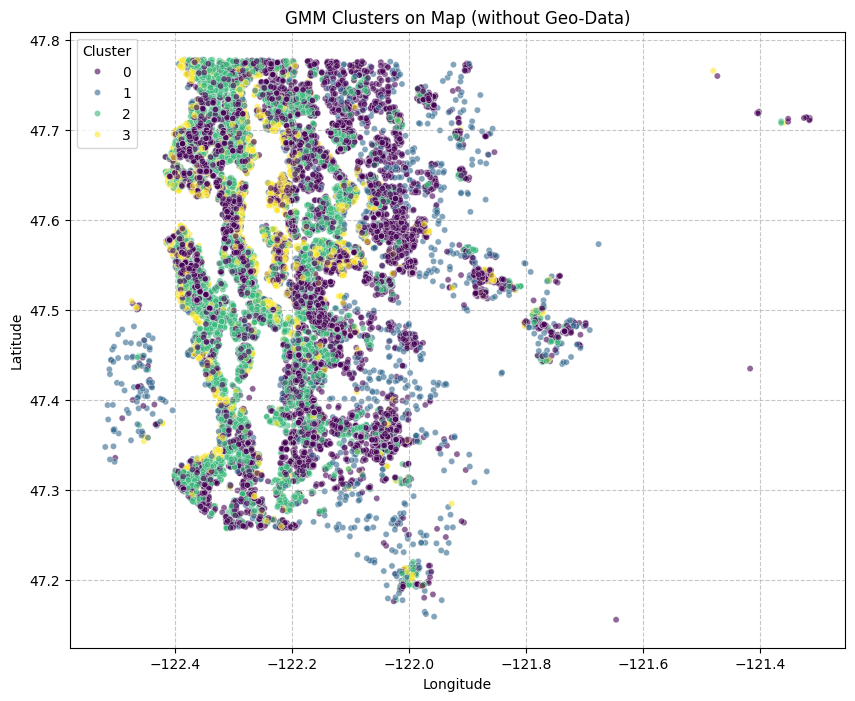

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot of latitude and longitude, colored by GMM cluster (no geo-data)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='GMM_Cluster_no_geo',
    palette='viridis', # Choose a color palette
    data=data,
    alpha=0.6,
    s=20 # Adjust point size for better visualization if needed
)

plt.title('GMM Clusters on Map (without Geo-Data)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

На этом графике GMM кластеров на карте, где кластеризация проводилась без использования географических данных (широты и долготы), скорее всего, мы увидим очень разрозненную картину. Кластеры, обнаруженные GMM, будут основаны на сочетании других признаков (цены, характеристик дома и т.д.), а не на географической близости. Следовательно, точки, принадлежащие к одному кластеру, могут быть географически очень сильно разбросаны по карте. Это означает, что, хотя GMM успешно выделила группы объектов по их внутренним характеристикам, эти группы не имеют очевидной географической привязки. Если все же какие-то географические паттерны проявятся, это может указывать на скрытую корреляцию между негеографическими признаками и местоположением.

## Вывод:

**Основные выводы анализа данных**
* Подготовка данных: Географические данные (столбцы 'lat' и 'long') были успешно удалены из DataFrame X_scaled_df, в результате чего был создан новый DataFrame X_scaled_no_geo с 17 признаками и 21 613 записями.
* K-Means кластеризация (без геоданных):
  * Оптимальное количество кластеров (k) было определено как 3 на основе визуального анализа графиков метода локтя и коэффициента силуэта.
  * Столбец KMeans_Cluster_no_geo, содержащий эти назначения кластеров, был добавлен в исходный DataFrame data.
* DBSCAN кластеризация (без геоданных):
  * Был построен график k-расстояний для помощи в выборе eps, используя k = 34 (в два раза больше количества признаков).
  * Тонкая настройка гиперпараметров с помощью перебора по сетке для eps (от 0.5 до 2.5) и min_samples (5, 10, 20, 34) выявила eps = 0.50 и min_samples = 34 как оптимальные, достигнув наивысшего коэффициента силуэта 0.3931.
  * Эта оптимальная конфигурация DBSCAN привела к образованию 13 различных кластеров и выявлению 20 129 шумовых точек из 21 613 общих точек данных, что указывает на то, что большинство точек данных были расценены DBSCAN как шум.
  * Столбец DBSCAN_Cluster_no_geo, включая шумовые точки, был добавлен в исходный DataFrame data.
* Кластеризация с использованием моделей гауссовых смесей (GMM) (без геоданных):
  * Оптимальное количество компонентов (k) было определено как 4 на основе оценки показателей AIC, BIC и коэффициента силуэта в диапазоне от 1 до 15 компонентов.
  * Столбец GMM_Cluster_no_geo, содержащий эти назначения кластеров, был добавлен в исходный DataFrame data.
* Визуализации: Для каждого алгоритма кластеризации (K-Means, DBSCAN, GMM) были сгенерированы точечные диаграммы с использованием исходных географических координат ('long' и 'lat') из DataFrame data, при этом точки были окрашены в соответствии с их соответствующими метками кластеров. Эти визуализации позволили оценить пространственное распределение кластеров, сформированных без явного использования географических признаков в процессе кластеризации.

* Заметное различие в идентификации шумовых точек алгоритмом DBSCAN (20 129 шумовых точек) по сравнению с K-Means и GMM (которые присваивают все точки к кластеру) указывает на фундаментально разные предположения о плотности и форме кластеров. Дальнейшее исследование характеристик идентифицированных «шумовых» точек и основных кластеров DBSCAN может дать ценные сведения об обнаружении выбросов или редко распределенных областях данных.
* Сравнение географических визуализаций кластеров, сгенерированных K-Means, DBSCAN и GMM (все обучены без геоданных), показывает, как каждый алгоритм неявно группирует данные на основе других признаков, которые могут коррелировать с географическими паттернами. Более глубокий анализ распределения признаков в этих различных назначениях кластеров может помочь понять основные движущие силы этих паттернов и определить, какой подход к кластеризации наиболее подходит для последующего доменного анализа или принятия решений.
